## Задание 1. Необходимые библиотеки
Список библиотек для работы. Убедитесь, что они установлены в окружении.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style='whitegrid', context='notebook')


## Задание 2. Загрузка и первичный анализ данных
Загружаем CSV с sep='\t', выводим первые 5 строк, информацию и проверяем пропуски.


In [4]:
# Укажите путь к файлу (файл уже загружён в окружение: marketing_campaign.csv)
path = 'marketing_campaign.csv'
df = pd.read_csv(path, sep='\t')
print('Размер датасета:', df.shape)
display(df.head(5))
display(df.tail(5))
print('\nИнформация о датасете:')
display(df.info())

print('\nПропуски по колонкам (количество):')
display(df.isna().sum().sort_values(ascending=False).head(20))

# Удаляем строки с пропусками (если предпочтительно сохранить данные - рассмотреть заполнение)
df = df.dropna().reset_index(drop=True)
print('\nПосле удаления пропусков размер:', df.shape)


Размер датасета: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurcha

None


Пропуски по колонкам (количество):


Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
dtype: int64


После удаления пропусков размер: (2216, 29)


## Задание 3. Визуализация данных
Три группы визуализаций: количественные (категориальные признаки), распределения и диаграммы расходов/кампаний.


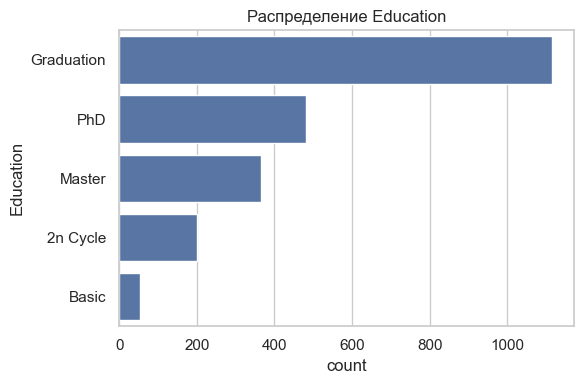

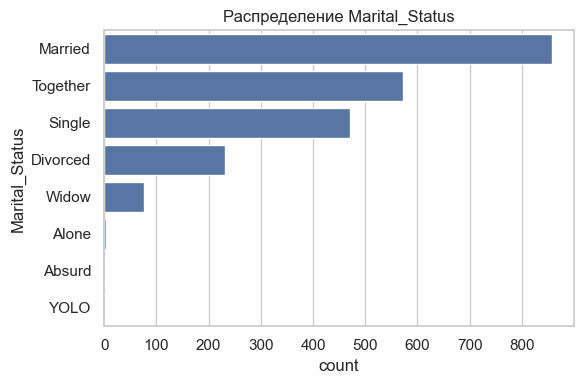

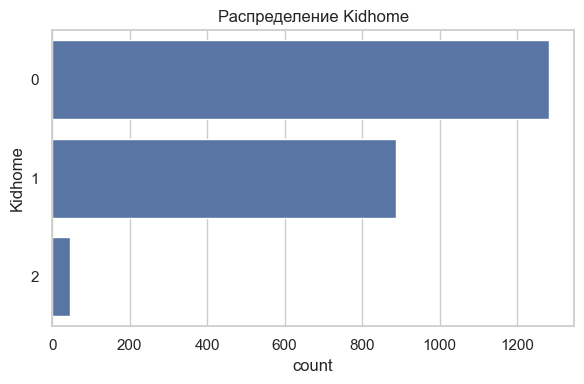

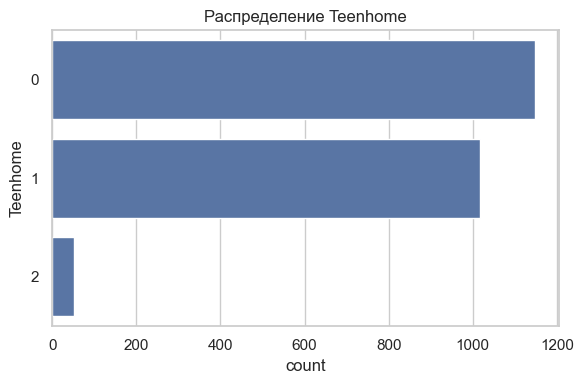

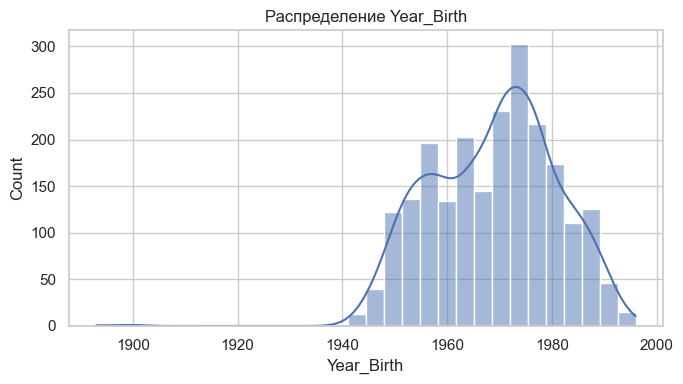

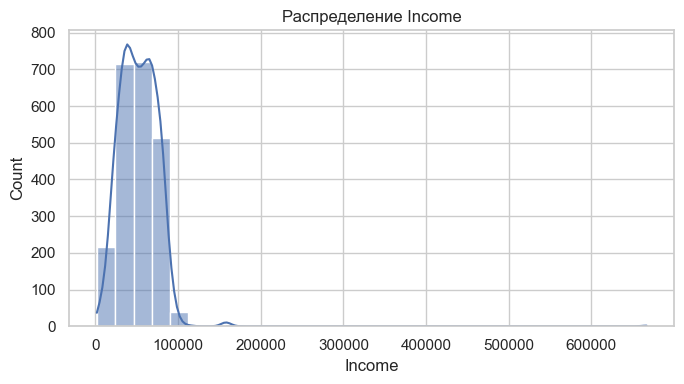

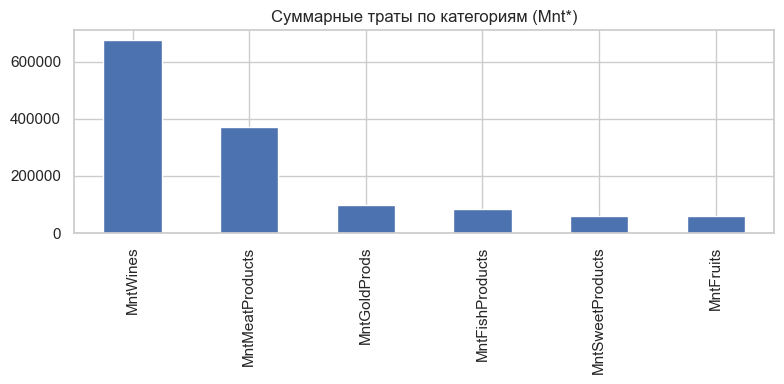

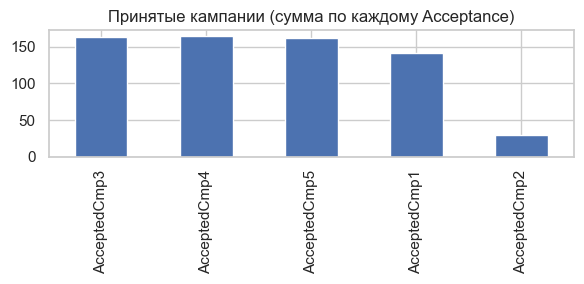

In [5]:
# 3.1 Количественные (категориальные) — Education, Marital_Status, Kidhome, Teenhome (если есть)
cat_examples = ['Education','Marital_Status','Kidhome','Teenhome']
present_cat = [c for c in cat_examples if c in df.columns]
for c in present_cat:
    plt.figure(figsize=(6,4))
    sns.countplot(y=c, data=df, order=df[c].value_counts().index)
    plt.title(f'Распределение {c}')
    plt.tight_layout()
    plt.show()

# 3.2 Распределения: Year_Birth, Income, Total_spent (после создания), Avg_spent (после создания)
num_examples = ['Year_Birth','Income']
present_num = [c for c in num_examples if c in df.columns]
for c in present_num:
    plt.figure(figsize=(7,4))
    sns.histplot(df[c], kde=True, bins=30)
    plt.title(f'Распределение {c}')
    plt.tight_layout()
    plt.show()

# 3.3 Диаграммы расходов/покупок/одобрения кампаний (суммарные значения)
mnt_cols = [c for c in df.columns if c.startswith('Mnt')]
if mnt_cols:
    plt.figure(figsize=(8,4))
    df[mnt_cols].sum().sort_values(ascending=False).plot(kind='bar')
    plt.title('Суммарные траты по категориям (Mnt*)')
    plt.tight_layout()
    plt.show()

cmp_cols = [c for c in df.columns if c.startswith('AcceptedCmp')]
if cmp_cols:
    plt.figure(figsize=(6,3))
    df[cmp_cols].sum().plot(kind='bar')
    plt.title('Принятые кампании (сумма по каждому Acceptance)')
    plt.tight_layout()
    plt.show()


## Задание 4. Предобработка данных
Создаём новые признаки, форматируем даты и удаляем лишние столбцы.


In [6]:
# Копия для работы
df_proc = df.copy()

# Преобразование даты
if 'Dt_Customer' in df_proc.columns:
    df_proc['Dt_Customer'] = pd.to_datetime(df_proc['Dt_Customer'], dayfirst=True, errors='coerce')
    print('Min date:', df_proc['Dt_Customer'].min(), 'Max date:', df_proc['Dt_Customer'].max())

# Новые признаки
if 'Year_Birth' in df_proc.columns:
    df_proc['Age'] = 2021 - pd.to_numeric(df_proc['Year_Birth'], errors='coerce')

mnt_cols = [c for c in df_proc.columns if c.startswith('Mnt')]
if mnt_cols:
    df_proc['Total_spent'] = df_proc[mnt_cols].sum(axis=1)
    # Средняя сумма трат на покупку — если есть TotalPurchases или аналог
    if 'NumDealsPurchases' in df_proc.columns and 'NumWebPurchases' in df_proc.columns:
        total_purchases_cols = ['NumDealsPurchases','NumWebPurchases','NumStorePurchases','NumCatalogPurchases']
        df_proc['Total_Products'] = df_proc[total_purchases_cols].sum(axis=1)
        df_proc['Avg_spent'] = df_proc['Total_spent'] / df_proc['Total_Products'].replace({0:1})
    else:
        df_proc['Avg_spent'] = df_proc['Total_spent']

# Partner, Children, Family_size
if 'Marital_Status' in df_proc.columns:
    df_proc['Partner'] = df_proc['Marital_Status'].isin(['Married','Together']).astype(int)
if 'Kidhome' in df_proc.columns and 'Teenhome' in df_proc.columns:
    df_proc['Children'] = df_proc['Kidhome'] + df_proc['Teenhome']
else:
    if 'Children' not in df_proc.columns:
        df_proc['Children'] = 0
df_proc['Family_size'] = df_proc.get('Children',0) + df_proc.get('Partner',0) + 1

# Customer_For (days since join to 2021-12-31)
if 'Dt_Customer' in df_proc.columns:
    cutoff = pd.to_datetime('2021-12-31')
    df_proc['Customer_For'] = (cutoff - df_proc['Dt_Customer']).dt.days

# Удаляем технические столбцы
drop_cols = [c for c in ['Dt_Customer','Z_CostContact','Z_Revenue','Year_Birth','ID'] if c in df_proc.columns]
df_proc = df_proc.drop(columns=drop_cols, errors='ignore')

print('После предобработки shape:', df_proc.shape)
display(df_proc.head())


Min date: 2012-07-30 00:00:00 Max date: 2014-06-29 00:00:00
После предобработки shape: (2216, 32)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Complain,Response,Age,Total_spent,Total_Products,Avg_spent,Partner,Children,Family_size,Customer_For
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,1,64,1617,25,64.680000,0,0,1,3405
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,67,27,6,4.500000,0,2,3,2855
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,56,776,21,36.952381,1,0,2,3054
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,37,53,8,6.625000,1,1,3,2881
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,40,422,19,22.210526,1,1,3,2903


## Задание 5. Исследование данных и кодирование
Pairplot, удаление выбросов (IQR) и кодирование Education/Marital_Status.


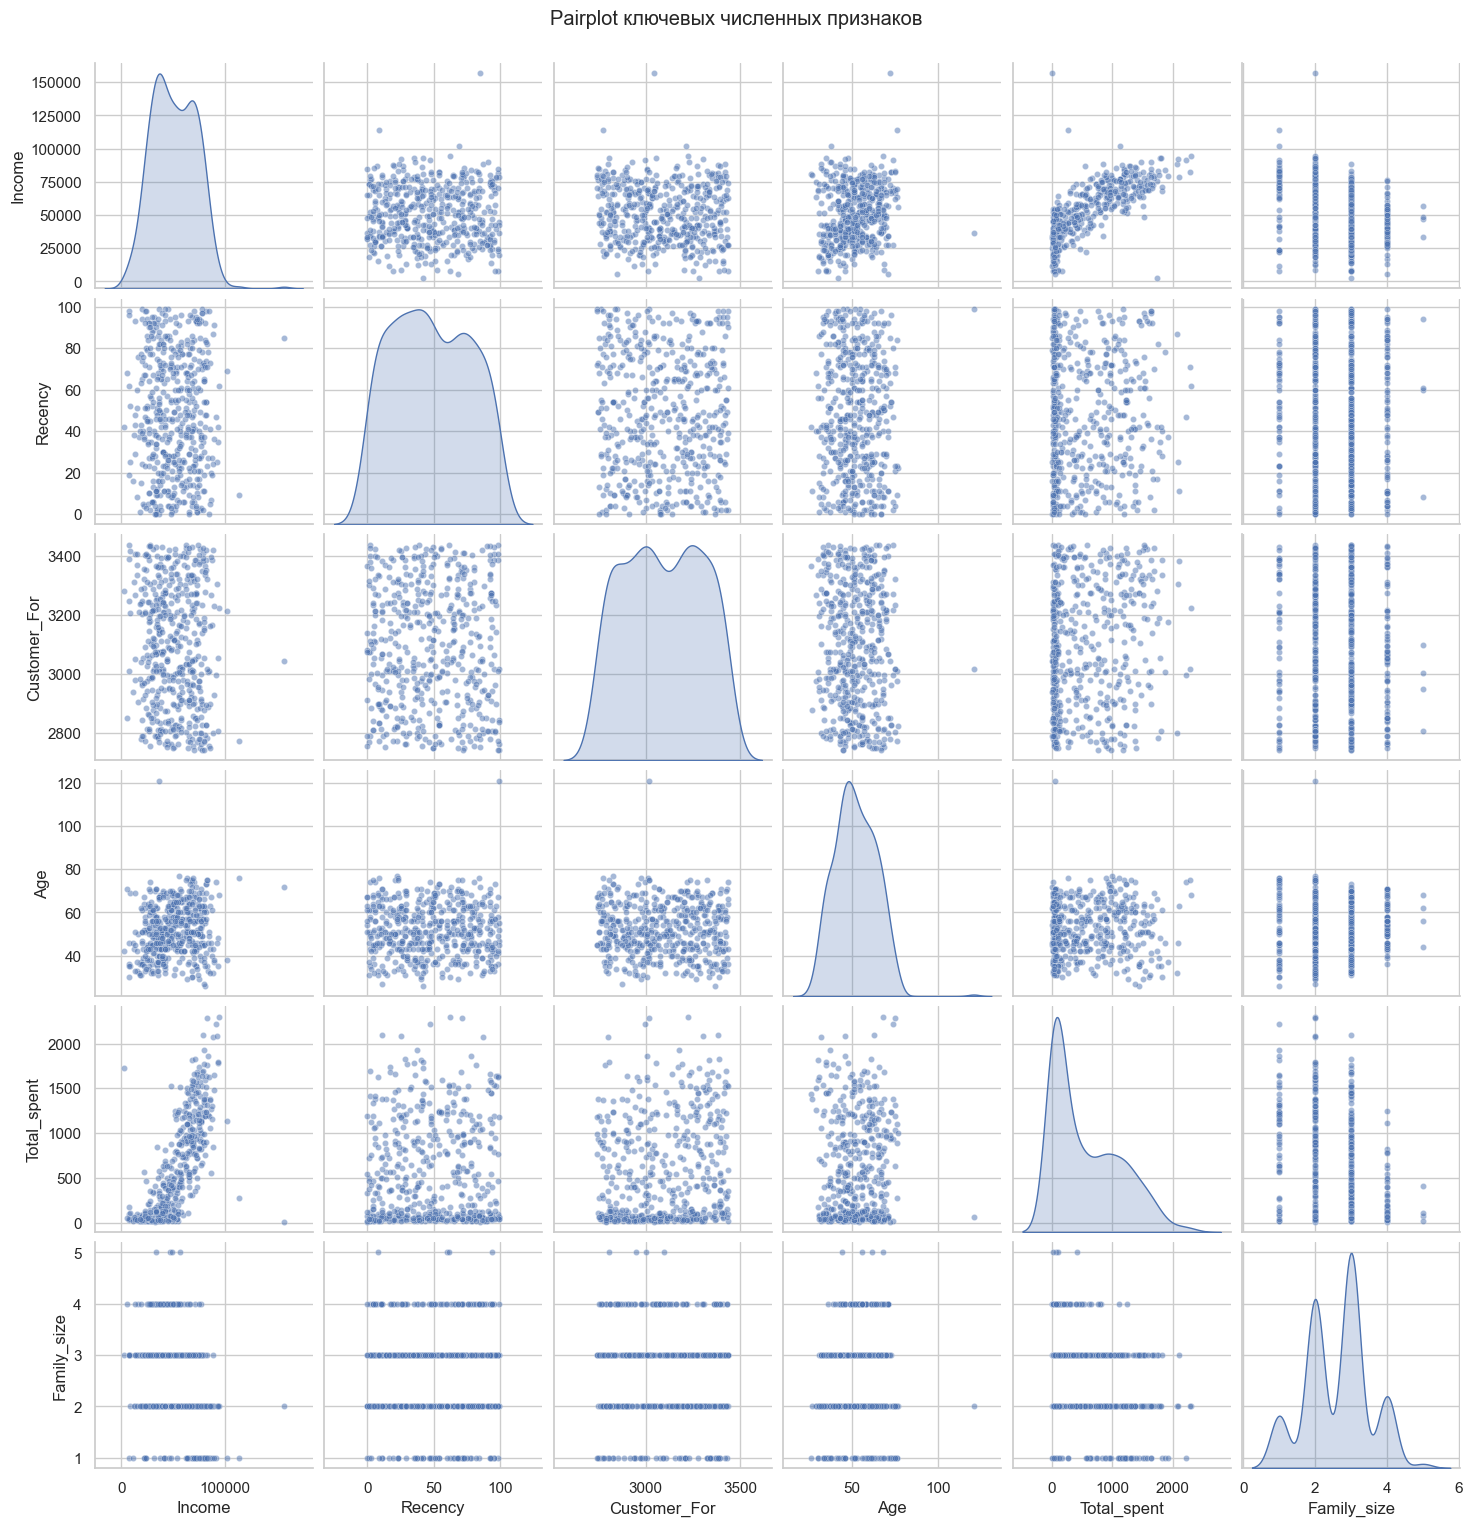

По Age удалено 3 строк (IQR)
По Income удалено 8 строк (IQR)
Закодирован столбец: Education -> Education_enc
Закодирован столбец: Marital_Status -> Marital_Status_enc


,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.000000,35196.000000,51287.000,68281.000000,113734.0
Kidhome,2205.0,0.442177,0.537132,0.000000,0.000000,0.000,1.000000,2.0
Teenhome,2205.0,0.506576,0.544380,0.000000,0.000000,0.000,1.000000,2.0
Recency,2205.0,49.009070,28.932111,0.000000,24.000000,49.000,74.000000,99.0
MntWines,2205.0,306.164626,337.493839,0.000000,24.000000,178.000,507.000000,1493.0
MntFruits,2205.0,26.403175,39.784484,0.000000,2.000000,8.000,33.000000,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.000000,16.000000,68.000,232.000000,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.000000,3.000000,12.000,50.000000,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.000000,1.000000,8.000,34.000000,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.000000,9.000000,25.000,56.000000,321.0


In [7]:
# Pairplot ключевых численных признаков
pair_cols = [c for c in ['Income','Recency','Customer_For','Age','Total_spent','Family_size'] if c in df_proc.columns]
if len(pair_cols) > 1:
    sns.pairplot(df_proc[pair_cols].dropna().sample(min(500, len(df_proc))), diag_kind='kde', plot_kws=dict(alpha=0.5, s=20))
    plt.suptitle('Pairplot ключевых численных признаков', y=1.02)
    plt.show()

# Удаление выбросов методом IQR для Age и Income
def drop_iqr(df_in, col):
    Q1 = df_in[col].quantile(0.25)
    Q3 = df_in[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5*IQR
    high = Q3 + 1.5*IQR
    return df_in[(df_in[col] >= low) & (df_in[col] <= high)]

for col in ['Age','Income']:
    if col in df_proc.columns:
        before = df_proc.shape[0]
        df_proc = drop_iqr(df_proc, col)
        after = df_proc.shape[0]
        print(f'По {col} удалено {before-after} строк (IQR)')

# Кодирование категорий
le = LabelEncoder()
for c in ['Education','Marital_Status']:
    if c in df_proc.columns:
        df_proc[c+'_enc'] = le.fit_transform(df_proc[c].astype(str))
        print(f'Закодирован столбец: {c} -> {c}_enc')

display(df_proc.describe().T)


## Задание 6. Корреляционный анализ и масштабирование признаков
Построим тепловую карту и подготовим scaled_df для PCA.


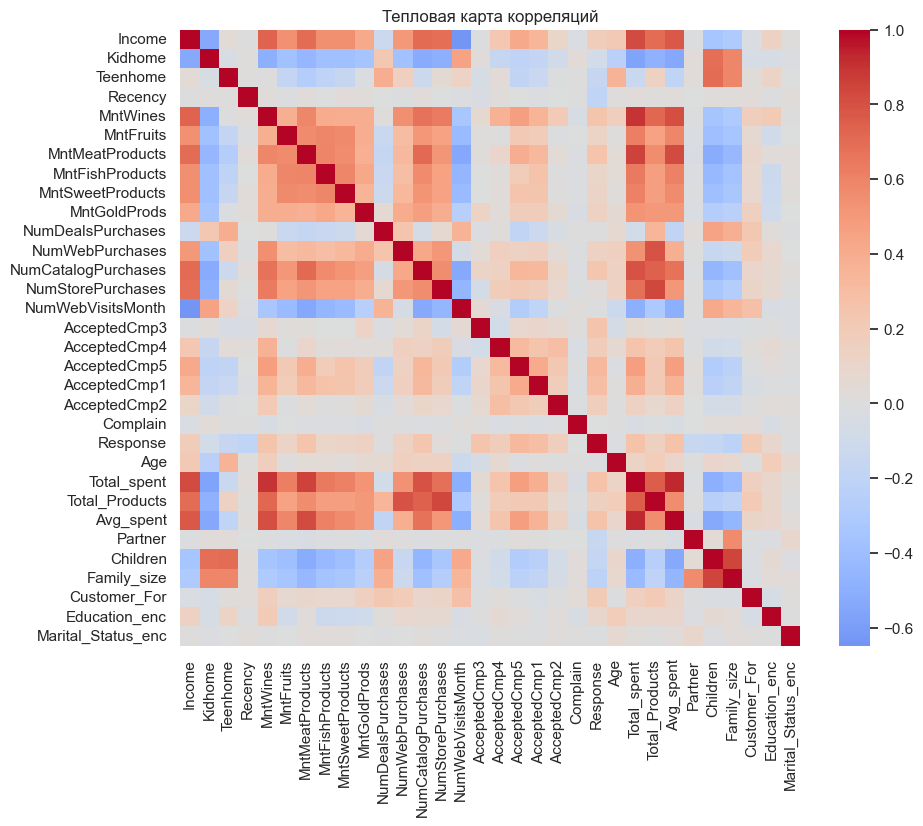

df2 shape: (2205, 27)
Числовые: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_spent', 'Total_Products', 'Avg_spent', 'Partner']
Категориальные (enc): ['Education_enc', 'Marital_Status_enc']
scaled_df shape: (2205, 27)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Products,Avg_spent,Partner,Children,Family_size,Customer_For,Education_enc,Marital_Status_enc,Education_enc,Marital_Status_enc
0,0.314651,-0.823405,-0.930767,0.310830,0.974566,1.548614,1.748400,2.449154,1.480301,0.849556,...,1.328161,1.123992,-1.347625,-1.266589,-1.759012,1.527183,-0.350162,0.254792,2,4
1,-0.254877,1.038757,0.906602,-0.380600,-0.874776,-0.638664,-0.731678,-0.652345,-0.635399,-0.735767,...,-1.167390,-0.984276,-1.347625,1.403420,0.448513,-1.188629,-0.350162,0.254792,2,4
2,0.965354,-0.823405,-0.930767,-0.795458,0.355155,0.568110,-0.175957,1.336263,-0.149031,-0.039771,...,0.802782,0.152619,0.742046,-1.266589,-0.655250,-0.205999,-0.350162,1.183413,2,5
3,-1.206087,1.038757,-0.930767,-0.795458,-0.874776,-0.563241,-0.667380,-0.506392,-0.586763,-0.755100,...,-0.904700,-0.909831,0.742046,0.068415,0.448513,-1.060245,-0.350162,1.183413,2,5
4,0.322136,1.038757,-0.930767,1.555404,-0.394659,0.417263,-0.217292,0.150396,-0.003121,-0.561768,...,0.540092,-0.363828,0.742046,0.068415,0.448513,-0.951612,1.432997,-0.673830,4,3


In [8]:
# Корреляционная матрица (числовые признаки)
plt.figure(figsize=(10,8))
num_corr = df_proc.select_dtypes(include=[np.number])
sns.heatmap(num_corr.corr(), cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций')
plt.show()

# Подготовка df2 (удаляем целевые столбцы, если они есть)
targets = [c for c in df_proc.columns if c.startswith('AcceptedCmp') or c in ['Complain','Response']]
df2 = df_proc.drop(columns=targets, errors='ignore').copy()
print('df2 shape:', df2.shape)

# Разделение числовых и категориальных (enc)
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df2.columns if c.endswith('_enc')]
print('Числовые:', num_cols[:20])
print('Категориальные (enc):', cat_cols)

# Масштабирование числовых признаков
scaler = StandardScaler()
scaled_num = scaler.fit_transform(df2[num_cols])
scaled_df = pd.DataFrame(scaled_num, columns=num_cols, index=df2.index)
# Добавляем категориальные столбцы (если есть)
if cat_cols:
    scaled_df = pd.concat([scaled_df.reset_index(drop=True), df2[cat_cols].reset_index(drop=True)], axis=1)
else:
    scaled_df = scaled_df.reset_index(drop=True)

print('scaled_df shape:', scaled_df.shape)
display(scaled_df.head())


## Задание 7. Понижение размерности с помощью PCA
Подберём количество компонент, объясняющих ≥90% дисперсии.


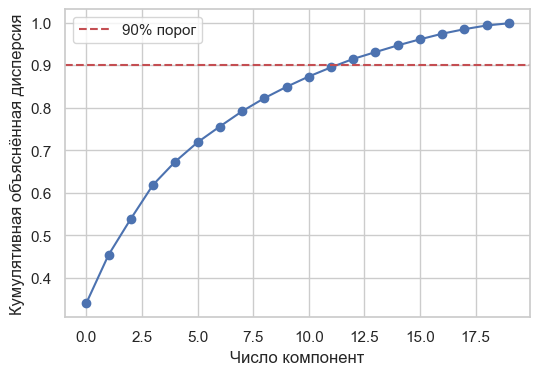

Выбрано компонент: 13


/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,5.039399,-0.755121,-0.999384,0.112764,2.251695,-0.239567,0.874865,-0.325014,1.712585,-0.524752,-0.206282,1.675152,0.467805
1,-3.206780,-0.009190,0.302367,0.385964,-1.240373,-1.872997,0.527487,-1.325169,0.671498,0.651831,0.092817,0.535901,0.055689
2,2.319957,-0.652484,-0.161770,1.798423,0.088732,-0.368332,-1.558145,0.471068,-0.827949,-0.719829,-0.508776,0.193415,0.508069
3,-3.016618,-1.399979,0.093924,1.844494,-0.192374,0.968138,-0.907944,-0.631392,-1.067408,-0.027047,0.044124,0.155052,-0.000969
4,-0.355277,1.095131,1.175039,-1.015412,-0.201556,1.988586,1.309040,-0.268889,-1.796059,-1.326664,-0.365393,0.857833,-0.287468


In [44]:
pca_full = PCA(n_components=min(20, scaled_df.shape[1]))
pca_full.fit(scaled_df.fillna(0))
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(6,4))
plt.plot(cum_var, marker='o')
plt.axhline(0.9, color='r', linestyle='--', label='90% порог')
plt.xlabel('Число компонент')
plt.ylabel('Кумулятивная объяснённая дисперсия')
plt.grid(True)
plt.legend()
plt.show()

n_comp = int(np.searchsorted(cum_var, 0.9) + 1)
print('Выбрано компонент:', n_comp)

pca = PCA(n_components=n_comp)
pca_trans = pca.fit_transform(scaled_df.fillna(0))
pca_df = pd.DataFrame(pca_trans, columns=[f'PC{i+1}' for i in range(pca_trans.shape[1])])
display(pca_df.head())


## Задание 8. Кластеризация K-Means
Найдём оптимальное K методом локтя и обучим модель для K=3.


/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/

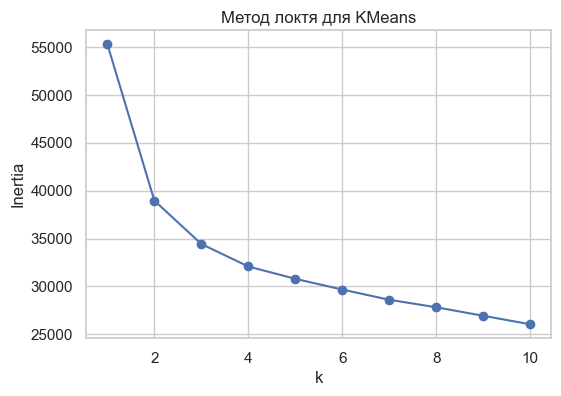

Распределение по кластерам:


/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/orn1xx/Downloads/matched_asteroids (1)/.venv/lib/

cluster
1    1036
2     611
0     558
Name: count, dtype: int64

In [45]:
# Метод локтя (инерция)
inertias = []
K_range = range(1,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Метод локтя для KMeans')
plt.grid(True)
plt.show()

# По условию задания выберем k=3
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(pca_df)
pca_df['cluster'] = labels
print('Распределение по кластерам:')
display(pca_df['cluster'].value_counts())


## Задание 9. 3D визуализация кластеров
Строим 3D scatter по первым трём компонентам (если они есть).


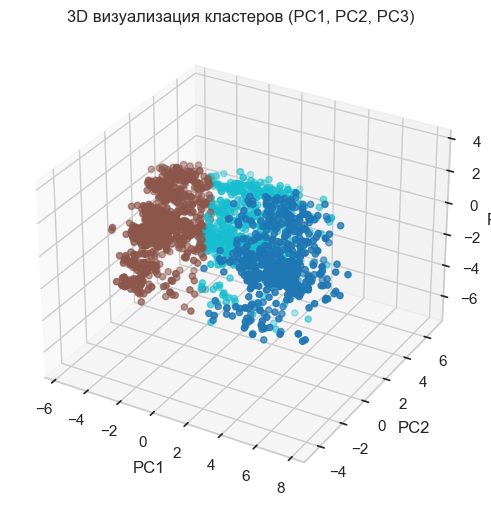

In [46]:
from mpl_toolkits.mplot3d import Axes3D
cols = [c for c in pca_df.columns if c.startswith('PC')]
if len(cols) >= 3:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['cluster'], cmap='tab10', s=20)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    plt.title('3D визуализация кластеров (PC1, PC2, PC3)')
    plt.show()
else:
    print('Меньше 3 компонент — 3D визуализация не построена')


## Задание 10. Профилирование кластеров и ключевые инсайты
Анализ размера кластеров, дохода, общих трат и средних трат по категориям.


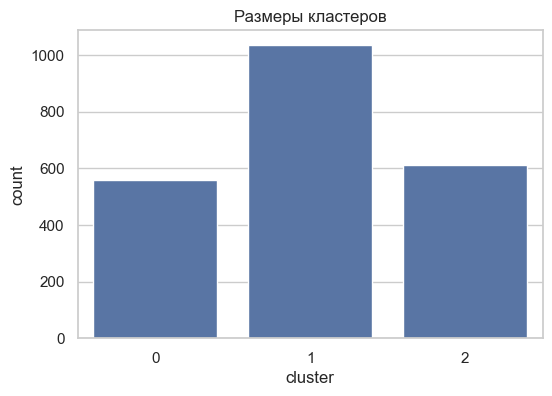

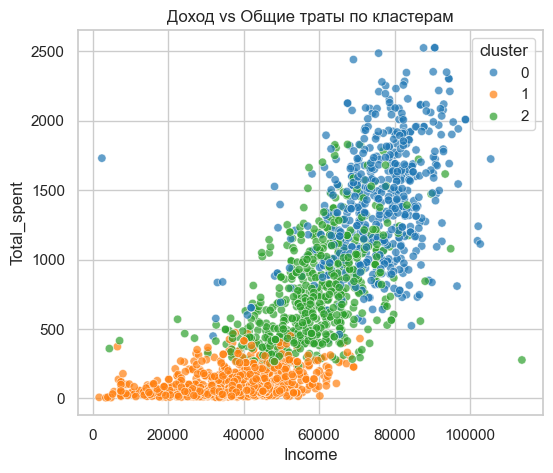

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
cluster,,,,,,
0,620.207885,68.770609,453.155914,100.949821,69.874552,77.741935
1,42.742278,5.242278,23.691120,7.827220,5.290541,15.702703
2,466.016367,23.590835,142.566285,30.792144,25.117840,61.371522


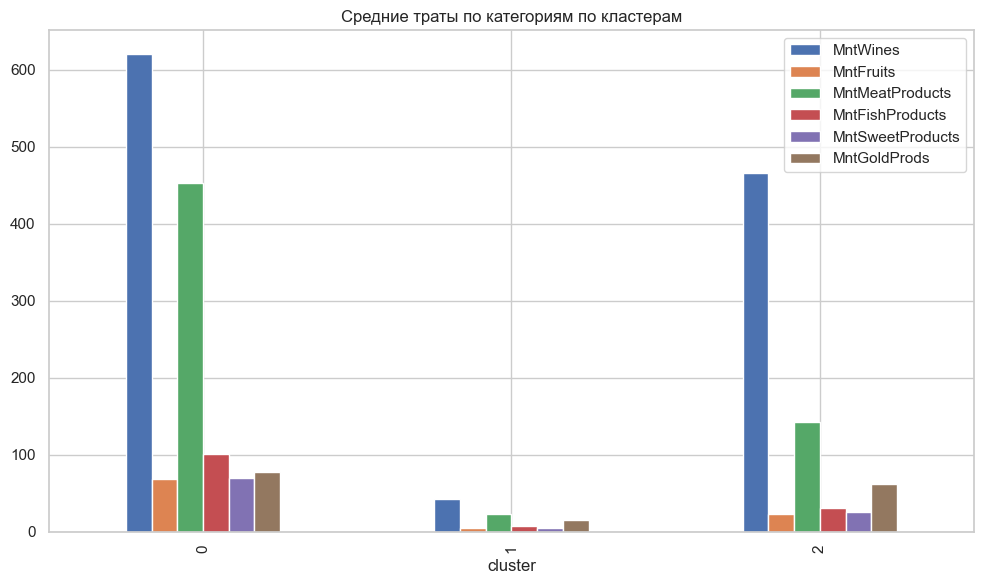

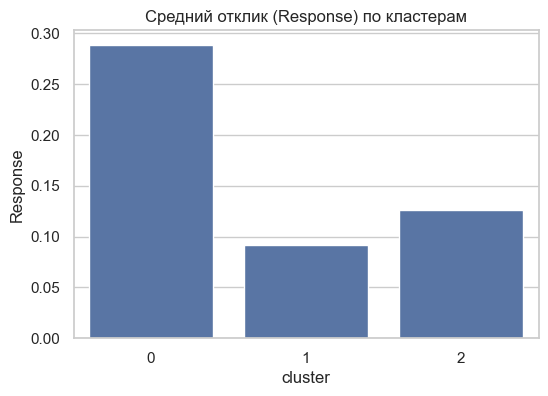

In [47]:
# Добавляем метки в df_proc для анализа
df_proc = df_proc.reset_index(drop=True).loc[pca_df.index].copy()
df_proc['cluster'] = pca_df['cluster'].values

# Размеры кластеров
plt.figure(figsize=(6,4))
sns.countplot(x='cluster', data=df_proc)
plt.title('Размеры кластеров')
plt.show()

# Доход vs общие траты
if 'Income' in df_proc.columns and 'Total_spent' in df_proc.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x='Income', y='Total_spent', hue='cluster', data=df_proc, palette='tab10', alpha=0.7)
    plt.title('Доход vs Общие траты по кластерам')
    plt.show()

# Средние траты по категориям
spend_cols = [c for c in df_proc.columns if c.startswith('Mnt')]
if spend_cols:
    cluster_means = df_proc.groupby('cluster')[spend_cols].mean()
    display(cluster_means)
    cluster_means.plot(kind='bar', figsize=(10,6))
    plt.title('Средние траты по категориям по кластерам')
    plt.tight_layout()
    plt.show()

# Частота отклика на кампании (например, Response)
if 'Response' in df_proc.columns:
    plt.figure(figsize=(6,4))
    sns.barplot(x='cluster', y='Response', data=df_proc.groupby('cluster')['Response'].mean().reset_index())
    plt.title('Средний отклик (Response) по кластерам')
    plt.show()


## Задание 11. Описание групп
Опишите три группы на основе полученных средних значений. Ниже — автоматическое краткое описание, которое можно дополнить вручную.


In [48]:
# Автоматическое сводное описание (пример)
desc = df_proc.groupby('cluster').agg({
    'Income':'mean','Total_spent':'mean','Family_size':'mean','Age':'mean','Customer_For':'mean'
}).round(2)
display(desc)

for idx, row in desc.iterrows():
    print(f"Кластер {idx}: средний доход={row['Income']}, средние траты={row['Total_spent']}, средний размер семьи={row['Family_size']}, средний возраст={row['Age']}")


,Income,Total_spent,Family_size,Age,Customer_For
cluster,,,,,
0,75449.69,1390.70,1.76,52.64,3097.50
1,34623.98,100.50,2.88,49.42,3063.69
2,58683.06,749.45,2.87,56.14,3148.39


Кластер 0: средний доход=75449.69, средние траты=1390.7, средний размер семьи=1.76, средний возраст=52.64
Кластер 1: средний доход=34623.98, средние траты=100.5, средний размер семьи=2.88, средний возраст=49.42
Кластер 2: средний доход=58683.06, средние траты=749.45, средний размер семьи=2.87, средний возраст=56.14


## Задание 12. Сравнительный анализ
Сравним демографические и расходные характеристики между группами.


In [49]:
# Таблица сравнения по ключевым признакам
compare_cols = ['Children','Family_size','Age','Income','Total_spent']
present_compare = [c for c in compare_cols if c in df_proc.columns]
compare_table = df_proc.groupby('cluster')[present_compare].mean().round(2)
display(compare_table)

# Сохраняем финальный датасет с кластерами
out_path = 'lab4_result_with_clusters.csv'
df_proc.to_csv(out_path, index=False)
print('Финальный файл сохранён:', out_path)


,Children,Family_size,Age,Income,Total_spent
cluster,,,,,
0,0.17,1.76,52.64,75449.69,1390.70
1,1.23,2.88,49.42,34623.98,100.50
2,1.18,2.87,56.14,58683.06,749.45


Финальный файл сохранён: lab4_result_with_clusters.csv
